# Assignment: More Matplotlib

### Problem 1: Line plots

In [1]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

In [2]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


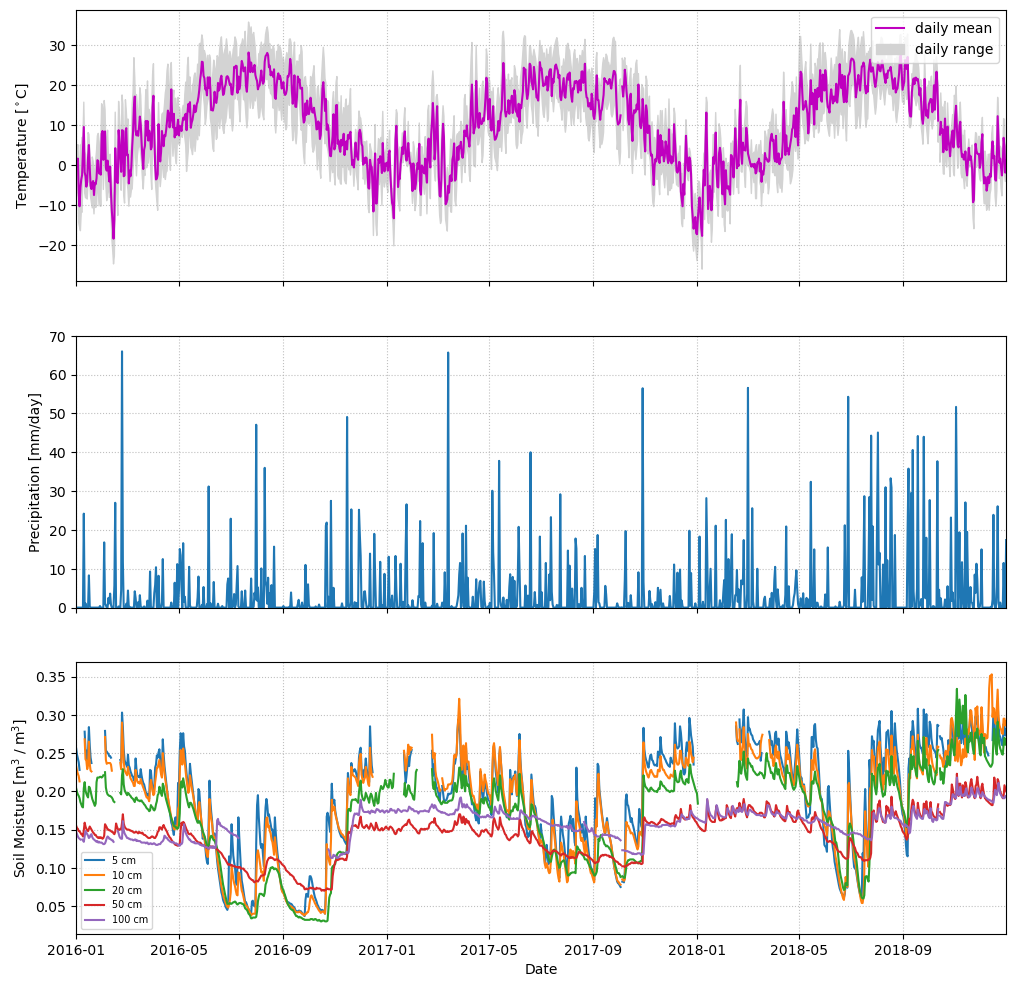

In [53]:
import numpy as np
from matplotlib import pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

ax_temp = axes[0]
ax_pre = axes[1]
ax_soil = axes[2]

# Temperature
ax_temp.plot(date, t_daily_mean, color='m', label='daily mean')
ax_temp.fill_between(date, t_daily_min, t_daily_max, color='lightgray', label='daily range')
ax_temp.set_ylabel('Temperature [$^\circ$C]')
ax_temp.grid(True, linestyle=':', alpha=0.8)
ax_temp.legend(loc='upper right')

# Precipitation
ax_pre.plot(date, p_daily_calc)
ax_pre.set_ylabel('Precipitation [mm/day]')
ax_pre.set_ylim(0, 70)
ax_pre.grid(True, linestyle=':', alpha=0.8)

# Soil Moisture
ax_soil.plot(date, soil_moisture_5, label='5 cm')
ax_soil.plot(date, soil_moisture_10, label='10 cm')
ax_soil.plot(date, soil_moisture_20, label='20 cm')
ax_soil.plot(date, soil_moisture_50, label='50 cm')
ax_soil.plot(date, soil_moisture_100, label='100 cm')
ax_soil.set_ylabel('Soil Moisture [m$^3$ / m$^3$]')
ax_soil.legend(loc='lower left', fontsize=7)
ax_soil.grid(True, linestyle=':', alpha=0.8)

# Set axis
ax_soil.set_xlabel('Date')
ax_soil.set_xlim(date[0], date[-1])

plt.show()

### Problem 2: Contour Plots

In [33]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values
print(lon)
print(lat)

[  0.      1.875   3.75    5.625   7.5     9.375  11.25   13.125  15.
  16.875  18.75   20.625  22.5    24.375  26.25   28.125  30.     31.875
  33.75   35.625  37.5    39.375  41.25   43.125  45.     46.875  48.75
  50.625  52.5    54.375  56.25   58.125  60.     61.875  63.75   65.625
  67.5    69.375  71.25   73.125  75.     76.875  78.75   80.625  82.5
  84.375  86.25   88.125  90.     91.875  93.75   95.625  97.5    99.375
 101.25  103.125 105.    106.875 108.75  110.625 112.5   114.375 116.25
 118.125 120.    121.875 123.75  125.625 127.5   129.375 131.25  133.125
 135.    136.875 138.75  140.625 142.5   144.375 146.25  148.125 150.
 151.875 153.75  155.625 157.5   159.375 161.25  163.125 165.    166.875
 168.75  170.625 172.5   174.375 176.25  178.125 180.    181.875 183.75
 185.625 187.5   189.375 191.25  193.125 195.    196.875 198.75  200.625
 202.5   204.375 206.25  208.125 210.    211.875 213.75  215.625 217.5
 219.375 221.25  223.125 225.    226.875 228.75  230.625 232.5  

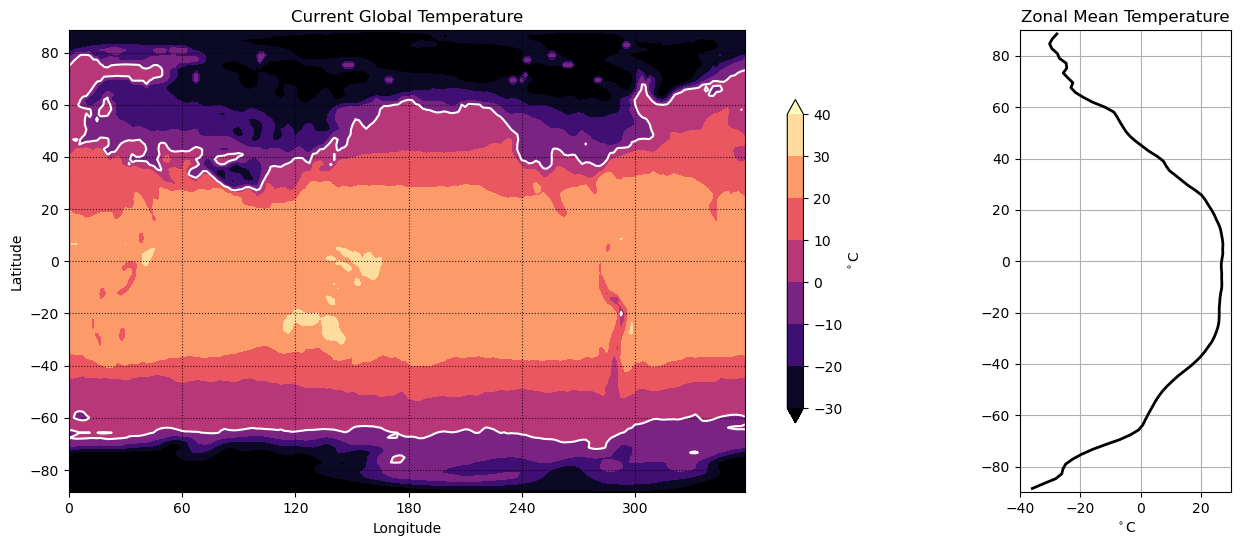

In [64]:
fig, axes = plt.subplots(figsize=(15, 6), ncols=2, gridspec_kw={'width_ratios': [4, 1]})
axis1 = axes[0]
axis2 = axes[1]

# Global Temperature
clevels = np.arange(-30, 41, 10)
cf = axis1.contourf(lon, lat, temp, levels=clevels, cmap='magma', extend='both')
axis1.contour(lon, lat, temp, levels=[0], colors='white')

axis1.set_title('Current Global Temperature')
axis1.set_xlabel('Longitude')
axis1.set_ylabel('Latitude')
axis1.grid(True, linestyle=':', color='k', alpha=0.8)

axis1.set_xticks(np.arange(0, 360, 60))

cbar = fig.colorbar(cf, ax=axis1, orientation='vertical', shrink=0.7, pad=0.05)
cbar.set_label('$^\circ$C')

# Zonal Mean
temp_zonal_mean = temp.mean(axis=1)

axis2.plot(temp_zonal_mean, lat, color='k', linewidth=2) 
axis2.set_title('Zonal Mean Temperature')
axis2.set_xlabel('$^\circ$C')
axis2.set_ylim(-90, 90)
axis2.set_xlim(-40, 30)
axis2.grid(True)

plt.show()

### Problem 3: Scatter plots

In [37]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

Unzipping contents of '/home/xg2467/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip' to '/home/xg2467/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip.unzip'


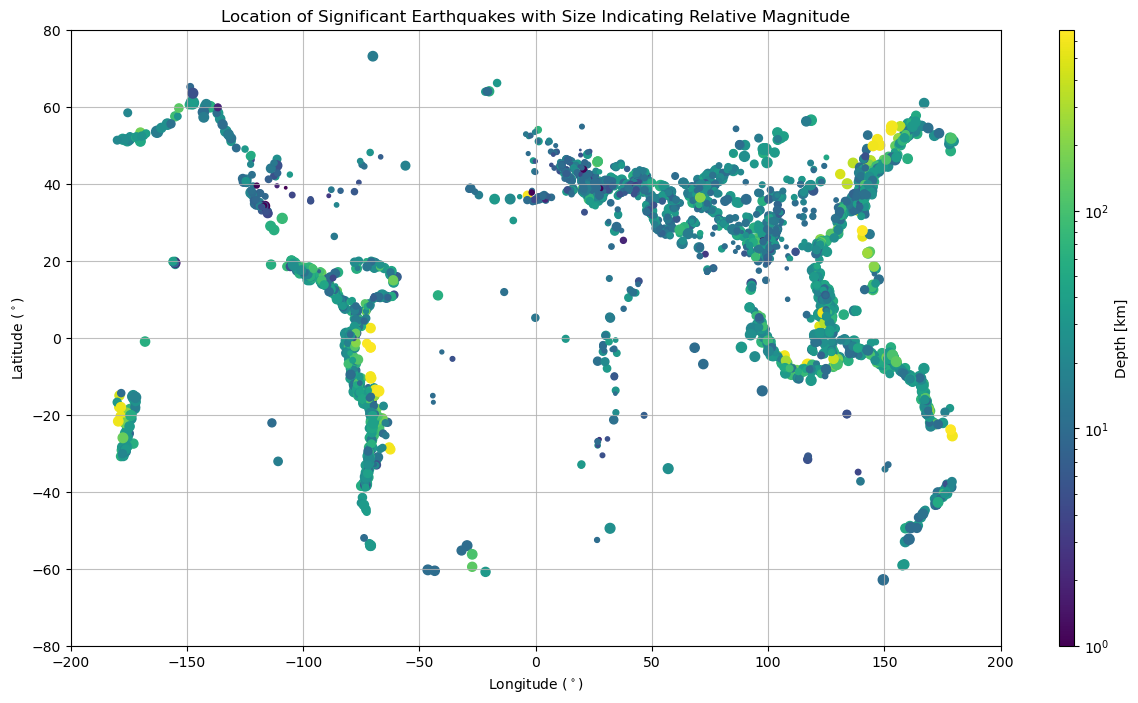

In [69]:
import matplotlib.colors as colors

fig, ax = plt.subplots(figsize=(15, 8))

sc = ax.scatter(longitude, latitude, c=depth, 
           s=magnitude**3 / 10, 
           alpha=1,            
           norm=colors.LogNorm())

cbar = fig.colorbar(sc, ax=ax, aspect=40, pad=0.05)
cbar.set_label('Depth [km]')

ax.set_title('Location of Significant Earthquakes with Size Indicating Relative Magnitude')
ax.set_xlabel('Longitude ($^\circ$)')
ax.set_ylabel('Latitude ($^\circ$)')

ax.grid(True, linestyle='-', alpha=0.8)

ax.set_xlim(-200, 200)
ax.set_ylim(-80, 80)

plt.show()